# Lorenz System: Euler → RK4 Extrapolation via Sequential SPRE


---
## 0. Imports & Global Settings

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                    EXPERIMENT CONFIGURATION                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# ── Kernel ────────────────────────────────────────────────────────────────────
# Options: 'matern12' | 'matern32' | 'matern52' | 'rbf'
KERNEL = ''  ##you can choose different kernels

# ── Methods to run ────────────────────────────────────────────────────────────
RUN_INDEPENDENT    = True
RUN_GLOBAL         = True
RUN_SEQ_REML       = True
RUN_SEQ_LOOCV      = True
RUN_LMC            = True
RUN_SLFM           = True

LAMBDAS = None

print(f"Config: kernel={KERNEL!r}  "
      f"methods=[{'ind ' if RUN_INDEPENDENT else ''}{'glob ' if RUN_GLOBAL else ''}{'seq-reml ' if RUN_SEQ_REML else ''}{'seq-loo ' if RUN_SEQ_LOOCV else ''}{'lmc ' if RUN_LMC else ''}{'slfm' if RUN_SLFM else ''}]")

Config: kernel='matern32'  methods=[ind glob seq-reml seq-loo lmc slfm]


In [2]:
import sys
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm as sp_norm


# ── Lorenz SPRE package ───────────────────────────────────────────────────────
from lorenz_sequential_BLPN import (
    LorenzSystem,
    run_lorenz_experiment,
    fit_reml_single, fit_sequential,
    geom_means, smooth_init,
    predict_at_zero, evaluate,
    run_lmc_lorenz,
    run_slfm_lorenz,
)

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(0)
torch.manual_seed(0)
warnings.filterwarnings('ignore')

# ── Benchmark target ─────────────────────────────────────────────────────────
COV_2SIGMA = float(2 * sp_norm.cdf(2) - 1)   # ≈ 0.9545
print(f"Target ±2σ coverage: {COV_2SIGMA:.4f}")

Target ±2σ coverage: 0.9545


---
## 1. Data Generation

Forward Euler at 12 step sizes; RK4 as ground truth.

In [ ]:
# ── Lorenz system settings ───────────────────────────────────────────────────
lorenz = LorenzSystem()   # default: σ=10, ρ=28, β=8/3, u₀=(-5,5,20)

H_BASE    = 0.01
H_FACTORS = np.arange(0.4, 1.6, 0.1)     # 12 step-size multipliers
h_vals    = H_BASE * H_FACTORS             # (12,) actual step sizes

REF_H_FACTOR = 0.01

ref_h = H_BASE * REF_H_FACTOR * H_FACTORS.min()   # FIX: 4e-5

T_MIN, T_MAX = 0.05, 1.0
N_TIME       = 40
T_list       = np.linspace(T_MIN, T_MAX, N_TIME)

print(f"Step sizes h: [{h_vals.min():.4f}, {h_vals.max():.4f}]  ({len(h_vals)} values)")
print(f"Reference h (RK4): {ref_h:.2e}")
print(f"Time points T: [{T_MIN}, {T_MAX}]  ({N_TIME} points)")
print()

# ── Quick sanity check ────────────────────────────────────────────────────────
test_euler = lorenz.euler(h_vals[-1], T_list[-1])
test_rk4   = lorenz.rk4_reference(ref_h, T_list[-1])
print(f"At T={T_list[-1]:.2f}, h={h_vals[-1]:.4f}:")
print(f"  Euler: {test_euler}")
print(f"  RK4:   {test_rk4}")
print(f"  Error: {np.abs(test_euler - test_rk4)}")


Step sizes h: [0.0040, 0.0160]  (13 values)
Reference h (RK4): 4.00e-05
Time points T: [0.05, 1.0]  (40 points)

At T=1.00, h=0.0160:
  Euler: [-8.69852693 -8.52644724 27.60338763]
  RK4:   [-5.39034594 -9.08085855 14.56357602]
  Error: [ 3.308181    0.55441131 13.03981161]


---
## 2. Run Full Experiment (Methods 1–4)

`run_lorenz_experiment` runs all four methods for all three coordinates.

In [ ]:
print("Running full Lorenz experiment (3 coordinates x 5 methods) ...")
print("This may take 2-5 minutes for lambda CV, LMC, and SLFM fitting.")
print()

results = run_lorenz_experiment(
    T_min         = T_MIN,
    T_max         = T_MAX,
    n_time_points = N_TIME,
    h_base        = H_BASE,
    h_factors     = H_FACTORS,
    ref_h_factor  = REF_H_FACTOR,
    # lambdas = {0: (10.0, 3.728), 1: (10.0, 3.728), 2: (10.0, 3.728)},  # OLD: fixed lambdas (skips CV)
    # lambdas       = None,   # FIX: auto-select via B-fold CV (contiguous folds, per paper)
    n_folds       = 5,
    lambda_s_grid = np.logspace(-1, 3, 7),
    lambda_l_grid = np.logspace(-1, 3, 7), 
    kernel        = KERNEL,
    verbose       = True,
)

print("\nDone!")



Running full Lorenz experiment (3 coordinates x 5 methods) ...
This may take 2-5 minutes for lambda CV, LMC, and SLFM fitting.


Coordinate 0 (x)
  Valid time points: 40/40
  [1/4] Independent REML fits …
    amp ∈ [0.0004893, 2981]
    ell ∈ [0.0003355, 128]
  [1b/4] Geometric Means: amp=8.6470  ell=1.9040
  [2/4] Using supplied λ_σ=1000  λ_ℓ=1000  (CV skipped)
  [3/4] Sequential SPRE joint MAP  λ_σ=1000  λ_ℓ=1000 …
    Converged=True  iters=177  fevals=196  MAP=9.6017
    amp ∈ [339.4904, 539.7863]
    ell ∈ [1.6780, 7.4305]
  [4/4] Predicting at h → 0 …
  [LMC] Fitting LMC baseline ...
[LMC] Fitting rank-2 LMC  (Matern3/2, T=40 tasks, n=13 obs, restarts=5) …
[LMC] amp=35.49  ell=0.05238  noise=0 (fixed)  NLL=-858.8454
[LMC] Cov±2σ=0.975  z_mean=+0.176  z_std=0.648  KS=0.267
  [SLFM] Fitting SLFM baseline ...
[SLFM] Fitting rank-2 SLFM  (Matern3/2, T=40 tasks, n=13 obs, restarts=5) ...
[SLFM] amps=[1.1026 1.5378]  ells=[0.3829 0.3411]  noise=0 (fixed)  NLL=319134.2958
[SLFM] Cov±2σ=0

### 3.5 Hyperparameter Profiles

Amplitude and lengthscale as functions of time point $T$.

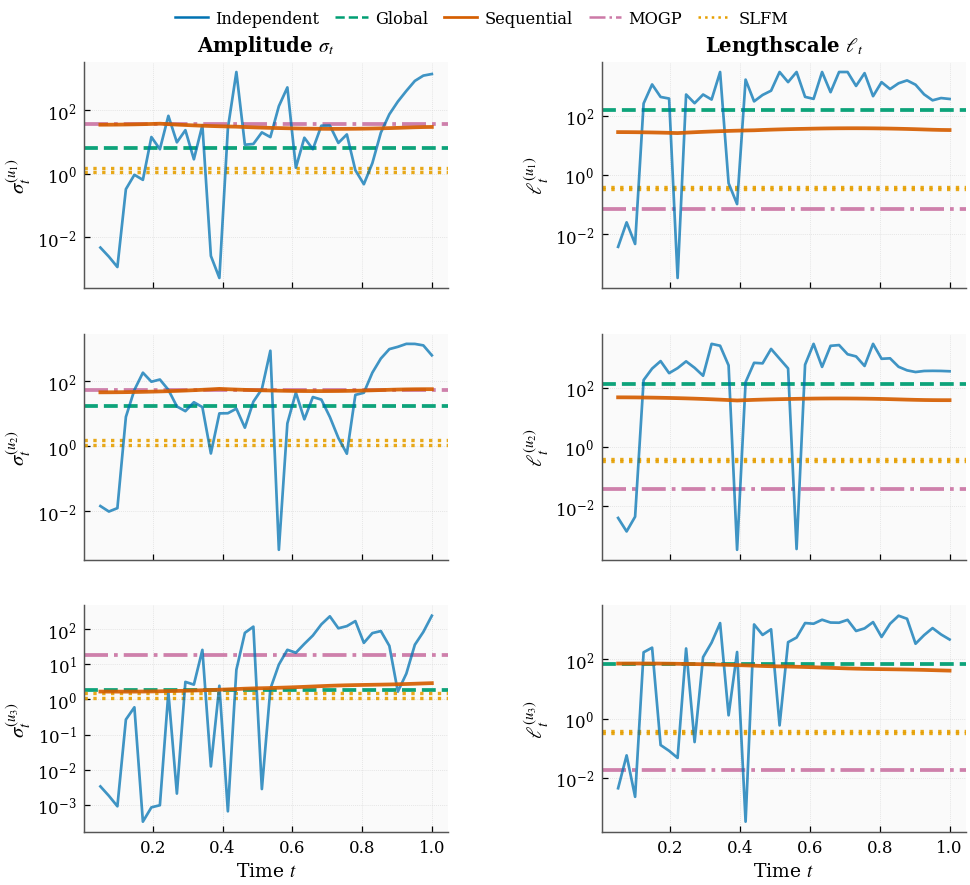

In [ ]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# ══════════════════════════════════════════════
#  RC PARAMS
# ══════════════════════════════════════════════
mpl.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":   "stix",
    "font.size":          9,
    "axes.linewidth":     0.75,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.labelsize":     9,
    "axes.titlesize":     9,
    "axes.titlepad":      4,
    "axes.labelpad":      3,
    "axes.grid":          True,
    "grid.color":         "#d8d8d8",
    "grid.linewidth":     0.35,
    "grid.linestyle":     ":",
    "grid.alpha":         1.0,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3.0,
    "ytick.major.size":   3.0,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

C_IND = "#0072B2"
C_GLO = "#009E73"
C_SEQ = "#D55E00"
C_LMC = "#CC79A7"
C_SLF = "#E69F00"


COORD_LABELS = [r'u_1', r'u_2', r'u_3']

# ══════════════════════════════════════════════
#  LAYOUT
# ══════════════════════════════════════════════
fig, axes = plt.subplots(
    3, 2,
    figsize=(6.8, 6.5),
    sharex="col",
)

fig.subplots_adjust(
    hspace=0.20, wspace=0.42,
    top=0.88,
    bottom=0.09,
    left=0.11, right=0.975,
)

# ══════════════════════════════════════════════
#  SHARED LEGEND
# ══════════════════════════════════════════════
legend_elements = [
    Line2D([0], [0], color=C_IND, lw=1.2, ls='-',   label='Independent'),
    Line2D([0], [0], color=C_GLO, lw=1.2, ls='--',  label='Global'),
    Line2D([0], [0], color=C_SEQ, lw=1.3, ls='-',   label='Sequential'),
    Line2D([0], [0], color=C_LMC, lw=1.2, ls='-.',  label='MOGP'),
    Line2D([0], [0], color=C_SLF, lw=1.2, ls=':',   label='SLFM'),
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.50, 0.948),
    ncol=5,
    fontsize=7.8,
    frameon=False,
    handlelength=2.0,
    columnspacing=1.0,
    handletextpad=0.45,
)

# ══════════════════════════════════════════════
#  COLUMN TITLES
# ══════════════════════════════════════════════
axes[0, 0].set_title(r'Amplitude $\sigma_t$', fontsize=9.5,
                     fontweight='semibold', pad=5)
axes[0, 1].set_title(r'Lengthscale $\ell_t$', fontsize=9.5,
                     fontweight='semibold', pad=5)

# ══════════════════════════════════════════════
#  PLOT LOOP
# ══════════════════════════════════════════════
for row, coord in enumerate(COORD_LABELS):
    r    = results[row]
    T    = r['T']
    ax_a = axes[row, 0]
    ax_l = axes[row, 1]

    # — Horizontal baselines —
    for key, color, lw, ls in [
        ('geomn', C_GLO, 1.8, '--'),
        ('lmc',   C_LMC, 1.8, '-.'),
    ]:
        d = r.get(key)
        if d is None:
            continue
        amp = d['amp'] if np.isscalar(d['amp']) else d['amp'][0]
        ell = d['ell'] if np.isscalar(d['ell']) else d['ell'][0]
        ax_a.axhline(amp, color=color, lw=lw, ls=ls, alpha=0.95, zorder=2)
        ax_l.axhline(ell, color=color, lw=lw, ls=ls, alpha=0.95, zorder=2)

    slfm_d = r.get('slfm')
    if slfm_d is not None:
        for a_j, l_j in zip(slfm_d['amps'], slfm_d['ells']):
            ax_a.axhline(a_j, color=C_SLF, lw=1.6, ls=':', alpha=0.9, zorder=2)
            ax_l.axhline(l_j, color=C_SLF, lw=1.6, ls=':', alpha=0.9, zorder=2)

    # — Time-varying lines —
    for key, color, lw, alpha, zo in [
        ('indep',      C_IND, 1.3, 0.75, 3),
        ('sequential', C_SEQ, 1.8, 0.92, 4),
    ]:
        d = r.get(key)
        if d is None or 'amp' not in d:
            continue

        if hasattr(d['amp'], '__len__') and len(d['amp']) > 1:
            ax_a.semilogy(T, d['amp'], '-', color=color, lw=lw,
                          alpha=alpha, zorder=zo)
            ax_l.semilogy(T, d['ell'], '-', color=color, lw=lw,
                          alpha=alpha, zorder=zo)
        else:
            amp = d['amp'] if np.isscalar(d['amp']) else d['amp'][0]
            ell = d['ell'] if np.isscalar(d['ell']) else d['ell'][0]
            ax_a.axhline(amp, color=color, lw=lw, ls='--', alpha=alpha, zorder=zo)
            ax_l.axhline(ell, color=color, lw=lw, ls='--', alpha=alpha, zorder=zo)

    # — Y labels —
    ax_a.set_ylabel(fr'$\sigma_t^{{({coord})}}$', fontsize=10, labelpad=2)
    ax_l.set_ylabel(fr'$\ell_t^{{({coord})}}$', fontsize=10, labelpad=2)

    if row == 2:
        ax_a.set_xlabel(r'Time $t$', fontsize=9)
        ax_l.set_xlabel(r'Time $t$', fontsize=9)

    # — Styling —
    for ax in [ax_a, ax_l]:
        ax.set_facecolor('#fafafa')
        ax.tick_params(which='both', direction='in', width=0.6)
        ax.yaxis.set_minor_locator(ticker.NullLocator())
        for spine in ['left', 'bottom']:
            ax.spines[spine].set_linewidth(0.7)
            ax.spines[spine].set_color('#555555')

# ══════════════════════════════════════════════
#  SAVE
# ══════════════════════════════════════════════
fig.savefig('lorenz_hyperparams_RBF.pdf')
fig.savefig('lorenz_hyperparams_RBF.png', dpi=300)
plt.show()